# COMENCEMOS !!! 

primero antes que nada hay que verificar y asegurarse de que todas laas librerías que necesitamos estén instaladas

In [5]:
!pip install qiskit
!pip install jupyter
!pip install sympy
!pip install matplotlib
!pip install pylatexenc
!pip install numpy
!pip install os
!pip install qiskit-ibm-runtime

ERROR: Could not find a version that satisfies the requirement os (from versions: none)
ERROR: No matching distribution found for os


una ves instaladas las librerias debemod llamarlas, el código abajo nos permitirá ver los datos del circuito sobre su representación en la esfera de bloch, el gráfico del circuito, el vector del circuito y el gráfico de probabilidades

In [6]:
import os
import numpy as np
from qiskit import QuantumCircuit
from qiskit.quantum_info import Operator, Statevector
from qiskit.visualization import plot_bloch_multivector, array_to_latex, plot_histogram # ¡Agregamos plot_histogram!
from IPython.display import display, Markdown
from numpy import sqrt


def analizar_circuito(qc: QuantumCircuit, titulo: str = "Análisis del Circuito", guardar_img: str = None):
    """
    Muestra el circuito, su vector de estado (Ket), la esfera de Bloch,
    la matriz unitaria y el histograma de probabilidades en Jupyter Notebook.
    """
    display(Markdown(f"<br>## {titulo}"))
    display(Markdown("---"))
    
    # 1. Dibujo del circuito
    display(Markdown("**1. Diagrama del Circuito:**"))
    fig_circuito = qc.draw(output='mpl')
    display(fig_circuito)
    
    if guardar_img:
        os.makedirs("imagenes", exist_ok=True) 
        ruta_completa = os.path.join("imagenes", guardar_img)
        fig_circuito.savefig(ruta_completa)
        display(Markdown(f"*Circuito guardado en: `{ruta_completa}`*"))
    
    # Extraemos el vector de estado una sola vez para usarlo en los siguientes pasos
    estado = Statevector(qc)
    
    # 2. Vector de estado en notación Ket
    display(Markdown("<br>**2. Vector de Estado (Notación Ket):**"))
    display(estado.draw('latex'))
    
    # 3. Esferas de Bloch
    display(Markdown("<br>**3. Visualización en la Esfera de Bloch:**"))
    display(plot_bloch_multivector(estado))

    # 5. Histograma de Probabilidades (¡Lo nuevo!)
    display(Markdown("<br>**5. Probabilidades de Medición teóricas:**"))
    probabilidades = estado.probabilities_dict()
    # plot_histogram genera un gráfico de barras muy profesional
    grafico_probs = plot_histogram(probabilidades, title="Probabilidades de los Estados Base")
    display(grafico_probs)

# Ejercicios de producto tensorial
En esta sección se inicializan los vectores de estado canónicos del espacio de Hilbert de un qubit $\mathcal{H}_2$ mediante la clase `Statevector`, correspondientes a la base computacional $\{|0\rangle, |1\rangle\}$ y a las bases superpuestas:
* $|+\rangle = \frac{1}{\sqrt{2}}(|0\rangle + |1\rangle)$
* $|-i\rangle = \frac{1}{\sqrt{2}}(|0\rangle - i|1\rangle)$ (denotado por la etiqueta `"l"` en Qiskit)

Asimismo, se definen los operadores elementales $\hat{O} \in \mathcal{L}(\mathcal{H}_2)$ utilizando `Operator`: la compuerta Hadamard ($H$), el operador identidad ($I$) y la compuerta Pauli-X ($X$).

In [7]:
from qiskit.quantum_info import Statevector, Operator
from numpy import sqrt

zero = Statevector.from_label("0")
one = Statevector.from_label("1")
plus = Statevector.from_label("+")
minus_i = Statevector.from_label("l")
H = Operator.from_label("H")
Id = Operator.from_label("I")
X = Operator.from_label("X")

phi = 'state_vector'.tensor('state_vector')
display(phi.draw('latex'))

AttributeError: 'str' object has no attribute 'tensor'

### 1. Producto tensorial de estados idénticos

Se construye el estado compuesto $|\psi\rangle \in \mathcal{H}_2 \otimes \mathcal{H}_2$ mediante el producto tensorial de dos estados fundamentales $|1\rangle$:

$$|\psi\rangle = |1\rangle \otimes |1\rangle = |11\rangle$$

En Qiskit, esta operación se evalúa tanto con el operador sobrecargado `^` como con el método explícito `.tensor()`.

In [8]:
display((zero^zero).draw('latex'))
phi = zero.tensor(zero)
display(phi.draw('latex'))

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

### Transformación unitaria conjunta: $H \otimes I$

En esta celda se calcula y visualiza la evolución del estado de dos qubits $|\phi\rangle$ bajo un operador compuesto:

1. **Producto tensorial de operadores (`H ^ Id`):** Se construye el operador global $U = H \otimes I$, donde la compuerta Hadamard ($H$) actúa sobre el primer subsistema y la identidad ($I$) sobre el segundo.
2. **Evolución del estado (`.evolve(...)`):** Se aplica la transformación lineal unitaria sobre el estado $|\phi\rangle = |+\rangle \otimes |-i\rangle$:

$$|\phi'\rangle = (H \otimes I)(|+\rangle \otimes |-i\rangle) = (H|+\rangle) \otimes (I|-i\rangle) = |0\rangle \otimes |-i\rangle = \frac{1}{\sqrt{2}}|00\rangle - \frac{i}{\sqrt{2}}|01\rangle$$

3. **Visualización (`.draw("latex")` y `display`):** Se renderiza el vector de estado resultante en notación matemática formal directamente en el notebook.

In [9]:
phi = plus.tensor(minus_i)
display(phi.evolve(H ^ Id).draw("latex"))

<IPython.core.display.Latex object>

### 4. Definición matricial de la compuerta CNOT y evolución

Se define de manera explícita el operador de dos qubits CNOT ($\text{CX}$) a través de su representación matricial estándar en la base computacional:

$$CX = \begin{pmatrix} 1 & 0 & 0 & 0 \\ 0 & 1 & 0 & 0 \\ 0 & 0 & 0 & 1 \\ 0 & 0 & 1 & 0 \end{pmatrix}$$

Posteriormente, se hace evolucionar el estado separable $|\psi\rangle = |+\rangle \otimes |0\rangle$ bajo este operador para evaluar el estado entrelazado resultante (estado de Bell $|\Phi^+\rangle$).

In [10]:
CX = Operator([[1, 0, 0, 0], [0, 1, 0, 0], [0, 0, 0, 1], [0,0,1,0]])
psi = plus.tensor(zero)
display(psi.evolve(CX).draw("latex"))


<IPython.core.display.Latex object>

### Construcción y verificación de la compuerta CNOT ($CX$)

En este bloque se define el operador de dos qubits CNOT mediante su matriz explícita en la base computacional:

$$CX = \begin{pmatrix} 1 & 0 & 0 & 0 \\ 0 & 1 & 0 & 0 \\ 0 & 0 & 0 & 1 \\ 0 & 0 & 1 & 0 \end{pmatrix}$$

Posteriormente, se evoluciona el estado separable $\vert{}\psi\rangle = \vert{}+\rangle \otimes \vert{}0\rangle$ bajo esta compuerta para generar el estado entrelazado de Bell $\vert{}\Phi^+\rangle = \frac{1}{\sqrt{2}}(\vert{}00\rangle + \vert{}11\rangle)$.

---

**Verificación de equivalencia con `QuantumCircuit`:**

Podemos comprobar que nuestra matriz coincide con la compuerta nativa `cx` de Qiskit extrayendo la matriz unitaria de un circuito mediante la clase `Operator`:

```python
from qiskit import QuantumCircuit
from qiskit.quantum_info import Operator

# Circuito con compuerta CX nativa (control: qubit 0, target: qubit 1)
qc = QuantumCircuit(2)
qc.cx(1,0)

# Obtener operador unitario del circuito y comparar matrices
u = Operator(qc)
display(u.data)

In [11]:
qc = QuantumCircuit(2)
qc.cx(1,0)
u = Operator(qc)
display(u.data)

array([[1.+0.j, 0.+0.j, 0.+0.j, 0.+0.j],
       [0.+0.j, 1.+0.j, 0.+0.j, 0.+0.j],
       [0.+0.j, 0.+0.j, 0.+0.j, 1.+0.j],
       [0.+0.j, 0.+0.j, 1.+0.j, 0.+0.j]])

# QuantumCircuit


partimos con el ejemplo de un sistema de 4 qbits de manera que aplicamos la compuerta hadamard en el primero

<br>## Análisis del Circuito

---

**1. Diagrama del Circuito:**

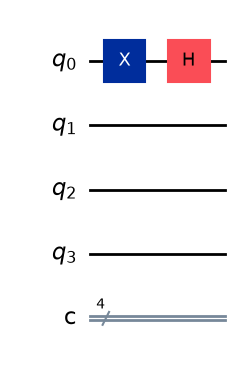

<br>**2. Vector de Estado (Notación Ket):**

<IPython.core.display.Latex object>

<br>**3. Visualización en la Esfera de Bloch:**

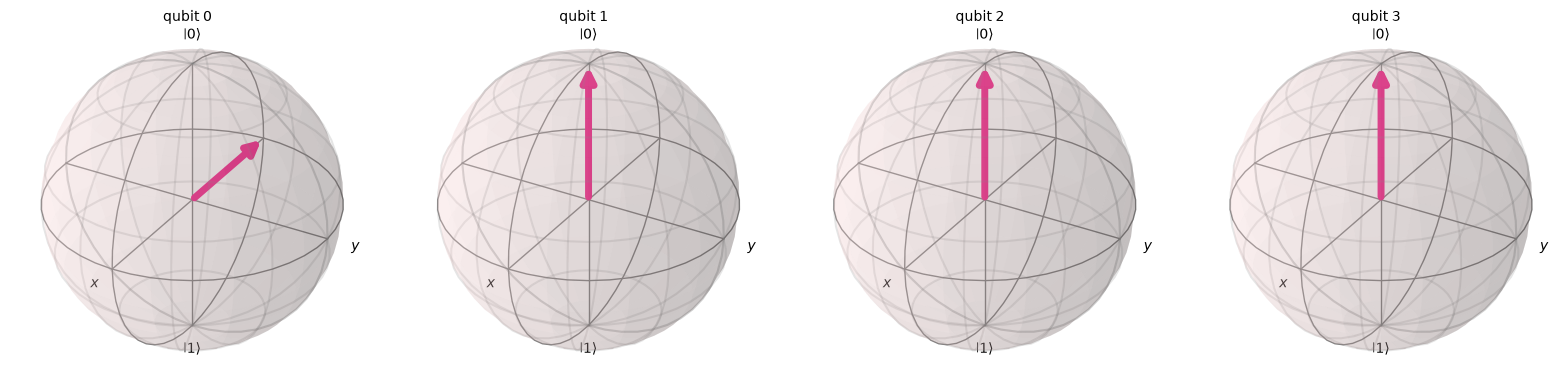

<br>**5. Probabilidades de Medición teóricas:**

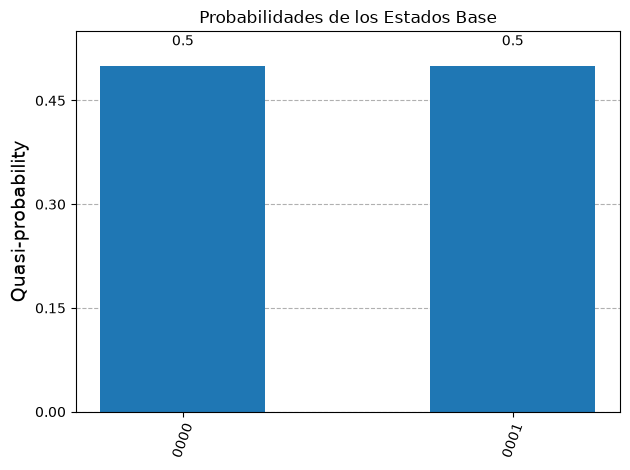

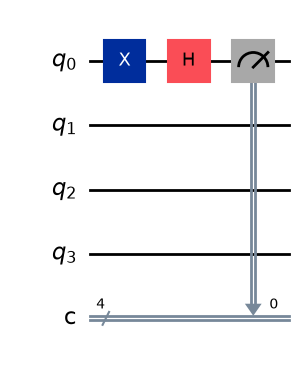

In [12]:
from qiskit import QuantumRegister, ClassicalRegister, QuantumCircuit
# aquí lo que hacemos es "crear 2 cajas" para guardar información
qreg_q = QuantumRegister(4,'q') # caja cuántica de 4 Qbits
creg_c = ClassicalRegister(4,'c') # caja clásica de 4 Bits
circuit = QuantumCircuit(qreg_q,creg_c) # aquí juntamos las 2 en mi circuito 
"""
y para qué sirve?
En los computadores cuánticos reales, necesitas cables cuánticos por donde viajan 
los estados en superposición, y cables clásicos (bits tradicionales de 0 y 1) para
guardar la información una vez que mides el circuito. Por defecto, todos los qubits
nacen en el estado fundamental |0>
"""
circuit.x(qreg_q[0])
circuit.h((qreg_q[0]))
analizar_circuito(circuit)
circuit.measure(qreg_q[0],creg_c[0])
display(circuit.draw('mpl'))



### Ejercicio 1
Implemente el siguiente estado: 
$$H|0\rangle$$

### Ejercicio 2
Implemente el siguiente estado: 
$$H|1\rangle$$

### Ejercicio 3
Implemente el siguiente estado: 
$$X|0\rangle$$

### Ejercicio 4
Implemente el siguiente estado: 
$$S|0\rangle$$

### Ejercicio 5
Implemente el siguiente estado: 
$$S^{\dagger}|0\rangle$$

### Ejercicio 6
Implemente el siguiente estado: 
$$S^{\dagger}|1\rangle$$

### Ejercicio 7
Implemente el siguiente estado secuencial: 
$$S\cdot H|0\rangle$$

### Ejercicio 8
Implemente el siguiente estado secuencial: 
$$H\cdot T\cdot H|0\rangle$$

## Circuitos

### Ejercicio 9
Implemente el siguiente producto tensorial: 
$$|0\rangle \otimes |0\rangle = |00\rangle$$

### Ejercicio 10
Implemente el siguiente producto tensorial: 
$$|1\rangle \otimes |1\rangle = |11\rangle$$

### Ejercicio 11
Implemente el siguiente producto tensorial: 
$$|1\rangle \otimes |0\rangle = |10\rangle$$

### Ejercicio 12
Implemente el siguiente producto tensorial: 
$$|0\rangle \otimes |1\rangle = |01\rangle$$

## Estados de Bell

### Ejercicio 13
Construya el circuito para: 
$$CNOT|00\rangle$$

### Ejercicio 14
Construya el circuito para: 
$$CNOT\cdot H|00\rangle$$

### Ejercicio 15
Construya el circuito para: 
$$CNOT\cdot H|10\rangle$$

### Ejercicio 16
Construya el circuito para: 
$$CNOT\cdot H|01\rangle$$

### Ejercicio 17
Construya el circuito para: 
$$CNOT\cdot H|11\rangle$$

### Ejercicio 18
Construya el circuito para: 
$$CNOT\cdot H\cdot Z|00\rangle$$


### Ejercicio 19
Construya el circuito de la figura 19 (Compuertas H, Z y CNOT).


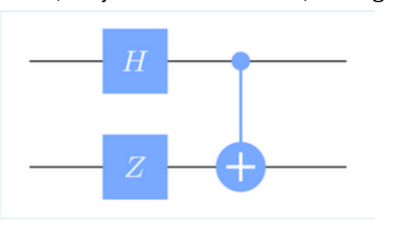

### Ejercicio 20
Construya el circuito de la figura 20 (Sistema con compuertas H, CNOT, Z).

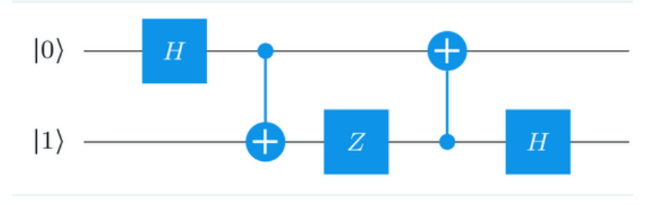

### Ejercicio 21
Construya el circuito de la figura 21 (Incluye compuertas X, H y S).


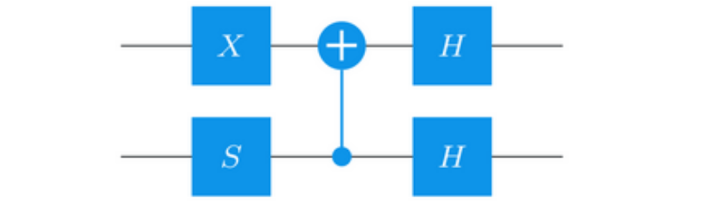

### Ejercicio 22
Implemente la compuerta: 
**Toffoli**

### Implemente el protocolo: 
**Alice y Bob**

In [13]:
from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister
from qiskit_aer import AerSimulator
from qiskit.visualization import plot_histogram, array_to_latex
from qiskit.result import marginal_distribution
from qiskit.circuit.library import UGate
from math import pi
import random

# Protocolo de Teleportación Cuántica: Explicación Paso a Paso

El protocolo de teleportación permite la transmisión de un estado cuántico arbitrario utilizando dos bits de comunicación clásica, a costa de consumir un par de qubits entrelazados (conocido como *ebit*). 

A continuación, se detalla el procedimiento exacto que siguen los dos participantes, Alice (emisora) y Bob (receptor).

## Paso 1: Preparación del Estado Entrelazado
Antes de iniciar la transmisión del mensaje, el protocolo asume la existencia de un canal cuántico previo.
* Alice y Bob inicializan un par de qubits (A para Alice, B para Bob) compartiendo un estado entrelazado.
* Específicamente, este par se inicializa en el estado de Bell máximo $\vert \phi^+ \rangle$. 

## Paso 2: Operaciones Locales de Alice
Alice posee el qubit arbitrario (llamémosle Q) cuyo estado $\vert \psi \rangle$ desea teleportar a Bob. Para ello, debe hacer interactuar Q con su mitad del par entrelazado (A).
* **Entrelazamiento local:** Alice aplica una compuerta CNOT, utilizando el qubit Q como control y su qubit A como objetivo.
* **Cambio de base:** Seguidamente, Alice aplica una compuerta de Hadamard (H) sobre el qubit Q.

## Paso 3: Medición y Comunicación Clásica
Tras realizar sus compuertas locales, el estado global del sistema ha cambiado y la información se ha "distribuido".
* Alice realiza una medición en la base computacional sobre el qubit A para obtener un bit clásico $a$, y sobre el qubit Q para obtener un bit clásico $b$.
* Debido al colapso de la función de onda, el estado cuántico original en el laboratorio de Alice se destruye.
* Finalmente, Alice envía estos bits clásicos ($a$ y $b$) a Bob a través de un canal de comunicación tradicional.

## Paso 4: Operaciones Condicionales de Bob (Recuperación)
El qubit de Bob (B) contiene ahora la información del estado original, pero "codificada" según los resultados aleatorios de la medición de Alice. Bob utiliza los bits clásicos recibidos para aplicar compuertas de forma condicional y corregir el estado:
* Si el bit $a = 1$, Bob aplica una compuerta de inversión de bit (Pauli-X) a su qubit.
* Si el bit $b = 1$, Bob aplica una compuerta de inversión de fase (Pauli-Z) a su qubit.

Una vez aplicadas estas correcciones condicionales, el qubit de Bob es matemáticamente idéntico al estado inicial $\vert \psi \rangle$ que Alice poseía, completando así la teleportación.

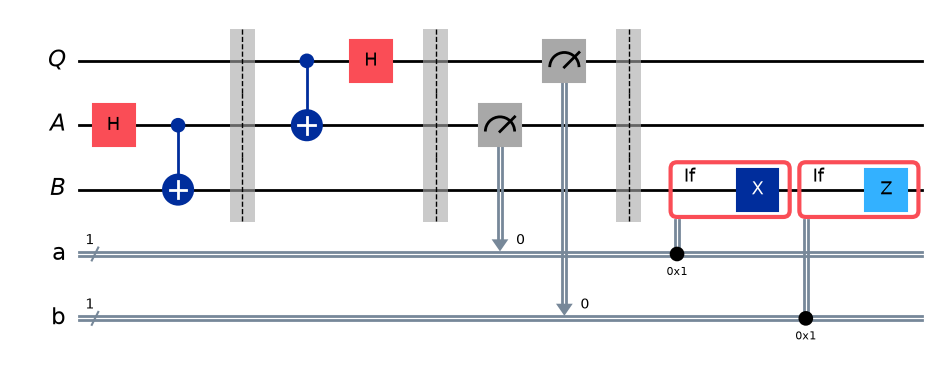

In [14]:
qubit = QuantumRegister(1, "Q")
ebit0 = QuantumRegister(1, "A")
ebit1 = QuantumRegister(1, "B")
a = ClassicalRegister(1, "a")
b = ClassicalRegister(1, "b")
protocol = QuantumCircuit(qubit, ebit0, ebit1, a, b)
# Prepare ebit used for teleportation
protocol.h(ebit0)
protocol.cx(ebit0, ebit1)
protocol.barrier()

# Alice's operations
protocol.cx(qubit, ebit0)
protocol.h(qubit)
protocol.barrier()
# Alice measures and sends classical bits to Bob
protocol.measure(ebit0, a)
protocol.measure(qubit, b)
protocol.barrier()
# Bob uses the classical bits to conditionally apply gates
with protocol.if_test((a, 1)):
    protocol.x(ebit1)
with protocol.if_test((b, 1)):
    protocol.z(ebit1)
display(protocol.draw(output="mpl"))

### Verificación del Protocolo de Teleportación

Este bloque de código tiene como objetivo comprobar que el protocolo de teleportación funciona correctamente. En lugar de teleportar un estado conocido, crea un estado cuántico aleatorio, lo teleporta y luego verifica matemáticamente si el estado recibido por Bob coincide con el original.

A continuación se detalla la lógica de cada sección del código:

*   **Generación de un estado aleatorio:** Primero, se genera una compuerta unitaria aleatoria (`random_gate`) utilizando ángulos generados al azar para los parámetros $\theta$, $\phi$ y $\lambda$. Esta compuerta se aplicará al estado inicializado $\vert 0\rangle$ de Q para obtener un vector de estado cuántico aleatorio que será el que Alice teleportará.
*   **Preparación del circuito de prueba:** Se inicializa un nuevo circuito (`test`) con los mismos registros del protocolo anterior y se le aplica la compuerta aleatoria al qubit de Alice (`qubit`). Se usa `test.barrier()` para separar visualmente esta etapa de preparación.
*   **Ejecución de la teleportación:** Mediante la función `compose`, se anexa el protocolo de teleportación completo (que ya habíamos definido) al circuito de prueba. En este punto, el estado cuántico viaja virtualmente de Alice a Bob.
*   **Verificación (La compuerta inversa):** Para verificar que el estado fue teleportado con éxito, se aplica la compuerta inversa (la transpuesta conjugada de la unitaria aleatoria original) al qubit de Bob (`ebit1`). 
*   **Medición del resultado:** Si la teleportación fue exitosa, el qubit de Bob contendrá el estado aleatorio exacto. Al aplicarle la compuerta inversa, el efecto se cancela y el estado debe regresar obligatoriamente a $\vert 0\rangle$. Finalmente, se mide este qubit en un nuevo registro clásico; el resultado de esta medición debería ser 0 con absoluta certeza.

In [15]:
random_gate = UGate(
theta=random.random() * 2 * pi,
phi=random.random() * 2 * pi,
lam=random.random() * 2 * pi,
)
display(array_to_latex(random_gate.to_matrix()))

<IPython.core.display.Latex object>

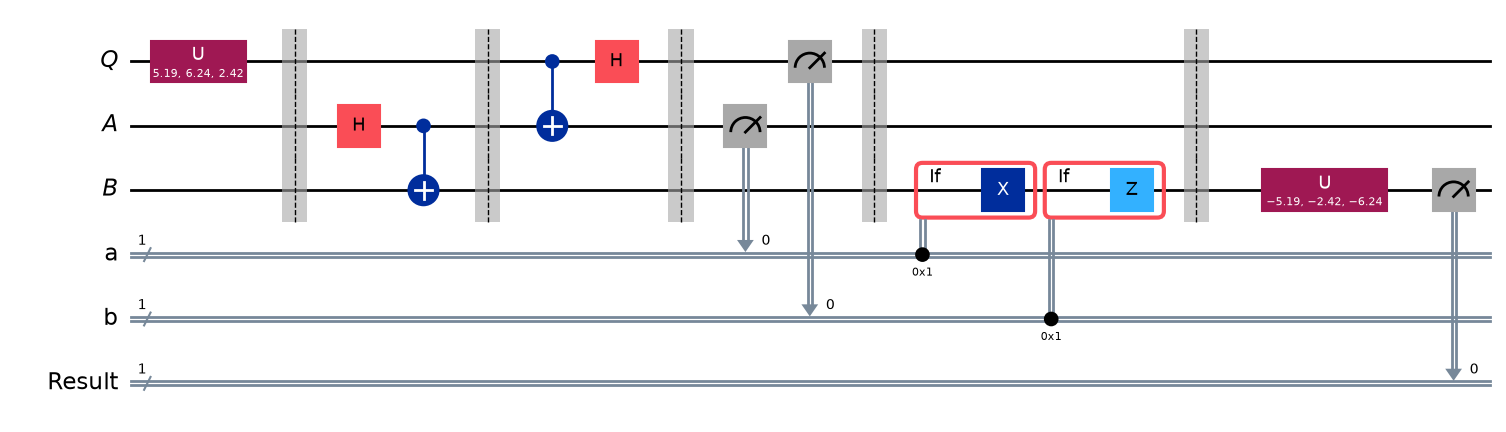

In [16]:
# Create a new circuit including the same bits and qubits used in the
# teleportation protocol.
test = QuantumCircuit(qubit, ebit0, ebit1, a, b)
# Start with the randomly selected gate on Q
test.append(random_gate, qubit)
test.barrier()
# Append the entire teleportation protocol from above.
test = test.compose(protocol)
test.barrier()
# Finally, apply the inverse of the random unitary to B and measure.
test.append(random_gate.inverse(), ebit1)
result = ClassicalRegister(1, "Result")
test.add_register(result)
test.measure(ebit1, result)
display(test.draw(output="mpl"))

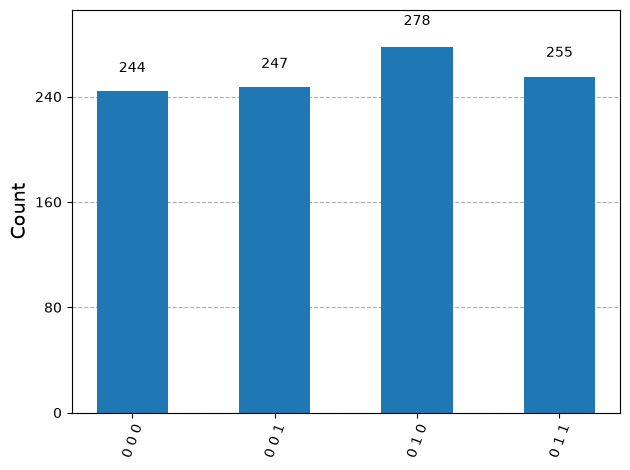

In [17]:
result = AerSimulator().run(test).result()
statistics = result.get_counts()
display(plot_histogram(statistics))

### Análisis de los Resultados de la Simulación

Este bloque de código ejecuta el circuito de prueba en el simulador cuántico (`AerSimulator`) y grafica un histograma con las estadísticas de los resultados obtenidos tras múltiples repeticiones (shots).

Al analizar el histograma generado, podemos observar el comportamiento de los tres bits clásicos involucrados en el experimento:

*   **El éxito de la teleportación (Bit de la izquierda):** En la convención de lectura de Qiskit, el bit más a la izquierda representa el registro que utilizamos para el resultado final de Bob. Si observamos las etiquetas del eje X en el gráfico (`0 0 0`, `0 0 1`, `0 1 0`, `0 1 1`), notamos que **este bit es siempre 0**. Esto demuestra que el qubit $\mathsf{Q}$ fue exitosamente teleportado hacia $\mathsf{B}$. Dado que aplicamos la compuerta inversa al estado de Bob antes de medir, obtener siempre un `0` comprueba que el estado que recibió era exactamente el mismo estado aleatorio que generamos al inicio.
*   **Las mediciones de Alice (Los dos bits de la derecha):** Los otros dos bits corresponden a la información clásica resultante de las mediciones que hizo Alice ($a$ y $b$). Como se puede ver en la altura de las barras del histograma (278, 262, 226, 258), estos resultados se distribuyen de manera aproximadamente uniforme entre las cuatro combinaciones posibles. Esto es el comportamiento probabilístico esperado al medir un estado fuertemente entrelazado.

**Conclusión:**
El histograma valida el protocolo. Aunque los resultados de las mediciones de Alice son completamente aleatorios (uniformes), las operaciones condicionales aplicadas por Bob logran corregir el estado en el 100% de los casos, garantizando la reconstrucción perfecta del estado cuántico original.

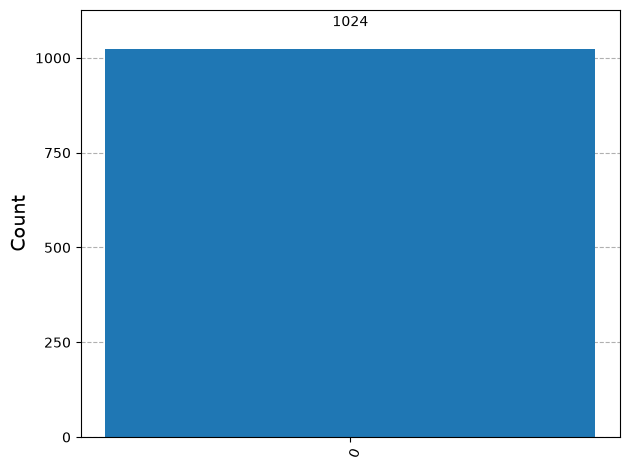

In [18]:

filtered_statistics = marginal_distribution(statistics,[2])
display(plot_histogram(filtered_statistics))

### Compilemos en un QC

In [48]:
from qiskit_ibm_runtime import QiskitRuntimeService
# Pasamos únicamente el string del apikey
QiskitRuntimeService.save_account(
    channel="ibm_quantum_platform", # opcional, acoerde a documentacion qiskit
    token="SZKzCksCwYFJGpZDAP6y2Gf2x-fiWqWO0GPzYI7UuZOA", #API KEY hay que crearla en IBM Quantum plataform
    instance= "crn:v1:bluemix:public:quantum-computing:us-east:a/fdd4743bce3d4d94bce59a2387de7313:d1a5aed7-ee26-4c0f-99f7-6f3376378064::", # este es el canal al cual uno se debe conectar, hay que cambiarlo con el CRN 
    overwrite=True # esto es debido a que como vamos a iniciar una cuenta cada vez que se ejecute el notebook, poder sobreescribir la cuenta guardada previamente
#   set_as_default = True con esto se guarda la cuenta como predeterminada     
)
"""

default account associated with that channel from the configuration 
file. Else, it will fall back to the overall default account, defined 
when calling save_account() with set_as_default=True.
"""


# Iniciamos el servicio (ya recuerda tu clave)
service = QiskitRuntimeService()


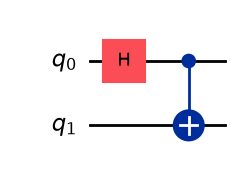

In [49]:
from qiskit import QuantumCircuit
from qiskit.quantum_info import SparsePauliOp
from qiskit.transpiler import generate_preset_pass_manager
from qiskit_ibm_runtime import QiskitRuntimeService
from qiskit_ibm_runtime import EstimatorOptions
from qiskit_ibm_runtime import EstimatorV2 as Estimator
from matplotlib import pyplot as plt
# Uncomment the next line if you want to use a simulator:
# from qiskit_ibm_runtime.fake_provider import FakeBelemV2


# Create a new circuit with two qubits
qc = QuantumCircuit(2)

# Add a Hadamard gate to qubit 0
qc.h(0)

# Perform a controlled-X gate on qubit 1, controlled by qubit 0
qc.cx(0, 1)

# Return a drawing of the circuit using MatPlotLib ("mpl").
# These guides are written by using Jupyter notebooks, which
# display the output of the last line of each cell.
# If you're running this in a script, use `print(qc.draw())` to
# print a text drawing.
qc.draw("mpl")


In [50]:
# Set up six different observables.

observables_labels = ["IZ", "IX", "ZI", "XI", "ZZ", "XX"]
observables = [SparsePauliOp(label) for label in observables_labels]

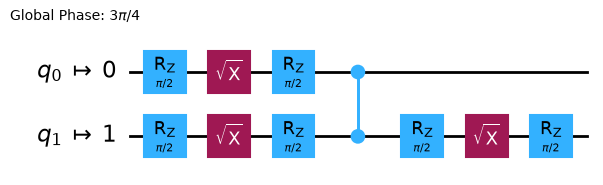

In [51]:
service = QiskitRuntimeService()

backend = service.least_busy(simulator=False, operational=True)

# Convert to an ISA circuit and layout-mapped observables.
pm = generate_preset_pass_manager(backend=backend, optimization_level=1)
isa_circuit = pm.run(qc)

isa_circuit.draw("mpl", idle_wires=False)

In [23]:

# Use the following code instead if you want to run on a simulator:

from qiskit_ibm_runtime.fake_provider import FakeBelemV2
backend = FakeBelemV2()
estimator = Estimator(backend)

# Convert to an ISA circuit and layout-mapped observables.

pm = generate_preset_pass_manager(backend=backend, optimization_level=1)
isa_circuit = pm.run(qc)
mapped_observables = [
    observable.apply_layout(isa_circuit.layout) for observable in observables
]

job = estimator.run([(isa_circuit, mapped_observables)])
result = job.result()

# This is the result of the entire submission. You submitted one Pub,
# so this contains one inner result (and some metadata of its own).

job_result = job.result()

# This is the result from our single pub, which had five observables,
# so contains information on all five.

pub_result = job.result()[0]


In [52]:
# Construct the Estimator instance.

estimator = Estimator(mode=backend)
estimator.options.resilience_level = 1
estimator.options.default_shots = 5000

mapped_observables = [
    observable.apply_layout(isa_circuit.layout) for observable in observables
]

# One pub, with one circuit to run against five different observables.
job = estimator.run([(isa_circuit, mapped_observables)])

# Use the job ID to retrieve your job data later
print(f">>> Job ID: {job.job_id()}")

>>> Job ID: dac8sj642tqs73ars5sg


In [53]:
# This is the result of the entire submission.  You submitted one Pub,
# so this contains one inner result (and some metadata of its own).
job_result = job.result()

# This is the result from our single pub, which had six observables,
# so contains information on all six.
pub_result = job.result()[0]

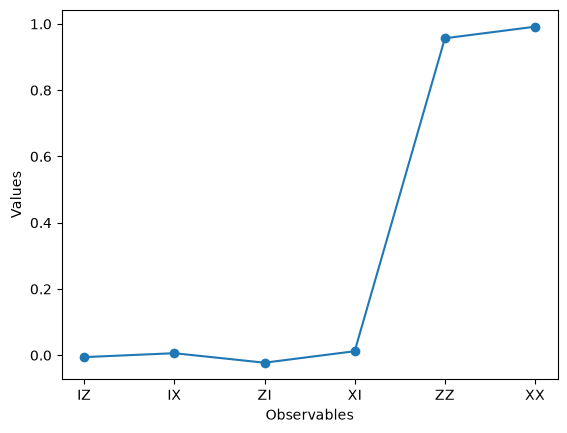

In [55]:
# Plot the result

values = pub_result.data.evs

errors = pub_result.data.stds

# plotting graph
plt.plot(observables_labels, values, "-o")
plt.xlabel("Observables")
plt.ylabel("Values")
plt.show()

In [27]:
def get_qc_for_n_qubit_GHZ_state(n: int) -> QuantumCircuit:
    """This function will create a qiskit.QuantumCircuit (qc)
        for an n-qubit GHZ state.

    Args:
        n (int): Number of qubits in the n-qubit GHZ state

    Returns:
        QuantumCircuit: Quantum circuit that generate the n-qubit GHZ state,
            assuming all qubits start in the 0 state
    """
    if isinstance(n, int) and n >= 2:
        qc = QuantumCircuit(n)
        qc.h(0)
        for i in range(n - 1):
            qc.cx(i, i + 1)
    else:
        raise Exception("n is not a valid input")
    return qc


# Create a new circuit with 100 qubits in the GHZ state
n = 100
qc = get_qc_for_n_qubit_GHZ_state(n)

In [28]:
# ZZII...II, ZIZI...II, ... , ZIII...IZ
operator_strings = [
    "Z" + "I" * i + "Z" + "I" * (n - 2 - i) for i in range(n - 1)
]

operators = [SparsePauliOp(operator) for operator in operator_strings]

In [29]:
service = QiskitRuntimeService()

backend = service.least_busy(
    simulator=False, operational=True, min_num_qubits=100
)
pm = generate_preset_pass_manager(optimization_level=1, backend=backend)

isa_circuit = pm.run(qc)
isa_operators_list = [op.apply_layout(isa_circuit.layout) for op in operators]

IBMInputValueError: 'No matching instances found for the following filters: .'

In [30]:
options = EstimatorOptions()
options.resilience_level = 1
options.dynamical_decoupling.enable = True
options.dynamical_decoupling.sequence_type = "XY4"

# Create an Estimator object
estimator = Estimator(backend, options=options)

In [31]:
# Submit the circuit to Estimator
job = estimator.run([(isa_circuit, isa_operators_list)])
job_id = job.job_id()
print(job_id)

NameError: name 'isa_operators_list' is not defined

ValueError: x and y must have same first dimension, but have shapes (99,) and (6,)

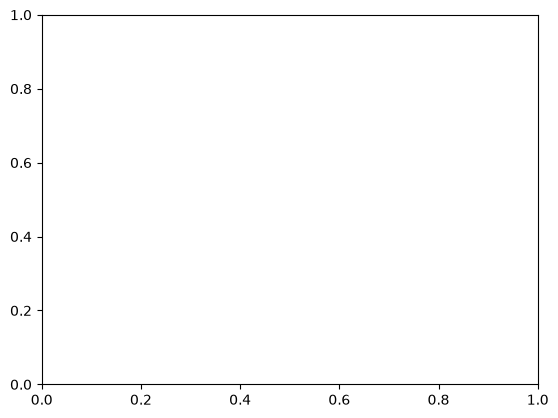

In [32]:
# data
data = list(range(1, len(operators) + 1))  # Distance between the Z operators
result = job.result()[0]
values = result.data.evs  # Expectation value at each Z operator.
values = [
    v / values[0] for v in values
]  # Normalize the expectation values to evaluate how they decay with distance.

# plotting graph
plt.plot(data, values, marker="o", label="100-qubit GHZ state")
plt.xlabel("Distance between qubits $i$")
plt.ylabel(r"$\langle Z_i Z_0 \rangle / \langle Z_1 Z_0 \rangle $")
plt.legend()
plt.show()

# ALice y Bob Criptografía cuántica BB84


# **Criptografía Cuántica**

Este taller se enfocará en el famoso protocolo de criptografía cuántica "BB84", publicado por Charles Bennett y Gilles Brassard en 1984. El principal objetivo del protocolo es crear una clave secreta entre dos individuos, Alice y Bob, la que luego podran usar para encriptar y desencriptar un mensaje oculto.

<img src="https://raw.githubusercontent.com/MIROptics/ECC2025/refs/heads/master/talleres/03_Criptografia_Cuantica/img/imag1.jpeg" width="900"/>

Durante el taller, te guiaremos a través de los diferentes pasos del protocolo para crear dicha clave secreta que permita descifrar nuestro mensaje oculto.

## Protocolo BB84

Los pasos del protocolo son los siguientes:

1. Primero, Alice elige dos cadenas de bit aleatorias, $k$ y $b$, donde cada una consta de $n$ bits. Su cadena de bits $k$ contiene los bits que ella desea codificar (con los cuales formará posteriormente la llave), mientras que $b$ determina las bases en la cual ella codificará sus bits. Entonces, para $b_i = 0$, ella codifica el i-ésimo qubit en la base Z o base computacional, por lo que si $k_i = 0$ el estado que ella envía es $|0\rangle$, y si $k_i=1$, ella envía el estado $|1\rangle $. Mientras que para $b_i=1$, ella codifica el i-ésimo qubit en la base X, por lo cual, para $k_i = 0$ ella envía $|+\rangle$ y para $k_i=1$, ella envía $|-\rangle$.

Para hacerlo más ilustrativo, representamos cada base con dos flechas perpendiculares de la siguiente forma

<img src="https://raw.githubusercontent.com/MIROptics/ECC2025/refs/heads/master/talleres/03_Criptografia_Cuantica/img/imag2.jpeg" width="600"/>

2. Una vez que Alice termina de codificar sus $n$ qubits, ella los envía a Bob. Por el lado de Bob, este también elige una cadena aleatoria de bits $\tilde{b}$ formada de $n$ bits que determina en qué bases va a realizar sus medidas. Él almacena los resultados de sus mediciones $\tilde{k}_i$ en una tabla juntos con los correspondientes bits $\tilde{b}_i$.

3. Por último, Alice y Bob comparan sus bits $b_i $ y $\tilde{b}_i$, con los que escogieron sus respectivas bases. Siempre que $b_i \neq \tilde{b}_i$, Bob midió en una base distinta a la que Alice codificó su qubit, por lo que obtiene cada resultado con probabilidad $\frac{1}{2}$. Sin embargo, si $b_i = \tilde{b}_i$, prepararon y midieron el qubit en la misma base, por lo que (a menos que alguien haya espiado) Bob obtendrá los bits de la clave que Alice codificó, $\tilde{k}_i = k_i$. Estos bits son los que componen entonces la clave.

En resumen, BB84 se puede ejemplicar de la siguiente manera

<img src="https://raw.githubusercontent.com/MIROptics/ECC2025/refs/heads/master/talleres/03_Criptografia_Cuantica/img/imag3.jpeg" width="800"/>

## ** BB84 ideal**

En primer lugar, veremos cómo el protocolo funciona cuando no hay nadie interceptando el mensaje entre Alice y Bob. Luego, veremos cómo ellos pueden detectar la presencia de este espía malicioso.

Como siempre, comenzaremos importando los módulos que necesitaremos durante el tutorial
## Paso 1

Alice primero debe generar de forma aleatoria sus cadenas de bits $k$ y $b$, a las que llamaremos `alice_bits` y `alice_bases`, respectivamente. Para esto, utilizamos la función `randint` de numpy para generar claves pseudo aleatorias

In [33]:
from qiskit_aer import Aer
from qiskit import QuantumCircuit
from qiskit.visualization import plot_histogram
from numpy.random import randint
import numpy as np
# Inicializamos una distribución aleatoria
np.random.seed(seed=0)

n = 100 # Largo de la cadena de bits

#  Generamos la cadena de bits aleatorios k de Alice
alice_bits = randint(2, size=n )

#  Generamos la cadena de bit aleatorios b de Alice
alice_bases = randint(2, size=n)

print(alice_bases)

[1 0 0 1 0 0 0 1 1 0 1 0 0 0 0 0 1 0 1 0 1 1 1 1 1 0 1 1 1 1 0 1 1 0 0 1 0
 0 0 0 1 1 0 0 1 0 1 1 1 1 0 0 0 1 0 1 1 1 0 1 0 0 1 0 1 1 0 0 1 0 1 0 1 0
 1 0 1 0 0 0 1 0 1 0 1 0 0 0 0 0 1 0 0 1 0 0 0 1 0 0]


## Paso 2

A continuación deberás completar la función `alice_prepare_qubit` que crea una lista `qubit`, donde cada elemento es un circuito representando el qubit que es enviado por alice. Las entradas de esta función son `a_bits` correspondientes a los bits que codifica Alice y `a_bases`, con la cadena de bits con que Alice prepara las bases.

**HINT:** Recuerda que si el bit en `a_bases` es `0`, implica preparar el estado en la base $Z$, mientras que si es `1`, Alice prepara el estado en la base $X$.

In [ ]:
def alice_prepare_qubit(a_bits, a_bases):
    '''
    Inputs:
        a_bits  (list) : bit string k
        a_bases (list): bit string b
    Outputs:
        qubit   (list): contains the circuit that generates each Alice's
                state according k and b.
    '''
    qubit = []
    for i in range(n):
        qc = QuantumCircuit(1,1)
    # ------------------------------------------------

    # ------------------------------------------------
        qc.barrier()
        qubit.append(qc)
    return qubit

In [35]:
#Aplicamos la función recien creada a todos los bits aleatorios de Alice
protocol = alice_prepare_qubit(alice_bits, alice_bases)

Notemos que el primer bit en `alice_bits` es `0`, y se codifica en la base $X$, por lo que el circuito del protocolo se ve de la siguiente manera

bit = 0
basis = 1


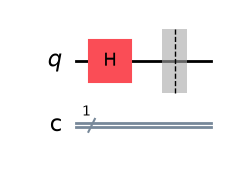

In [36]:
print('bit = %i' % alice_bits[0])
print('basis = %i' % alice_bases[0])
protocol[0].draw(output='mpl')

bit = 1
basis = 0


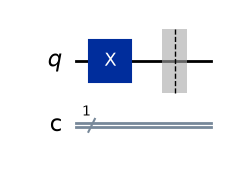

In [37]:
# otro ejemplo de como acceder a un bit y su base correspondiente
bit_index = 4
print('bit = %i' % alice_bits[bit_index])
print('basis = %i' % alice_bases[bit_index])
protocol[bit_index].draw(output='mpl')

## Paso 3

Generamos una cadena aleatoria $\tilde{b}$ para Bob que llamaremos `bob_bases` y que determinará en qué base realizará su medida

In [38]:
#  Generamos la cadena de bit aleatorios b tilde de Bob
bob_bases = randint(2, size=n)

print(bob_bases)

[1 0 1 0 0 1 1 0 0 0 1 1 0 0 0 0 0 1 0 1 0 0 0 1 1 1 0 0 1 1 1 1 0 0 0 1 1
 0 1 0 0 1 0 1 1 1 1 0 0 0 1 1 1 0 1 1 1 1 0 0 1 1 0 0 0 1 1 0 1 1 1 1 1 0
 0 0 1 0 1 0 1 1 0 0 0 1 0 0 1 1 1 1 0 1 0 0 0 0 1 1]


Ahora debemos medir (como Bob) usando `measure_qubit`  y almacenar los resultados en la lista `measurements`.

base = 1


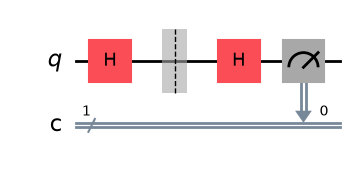

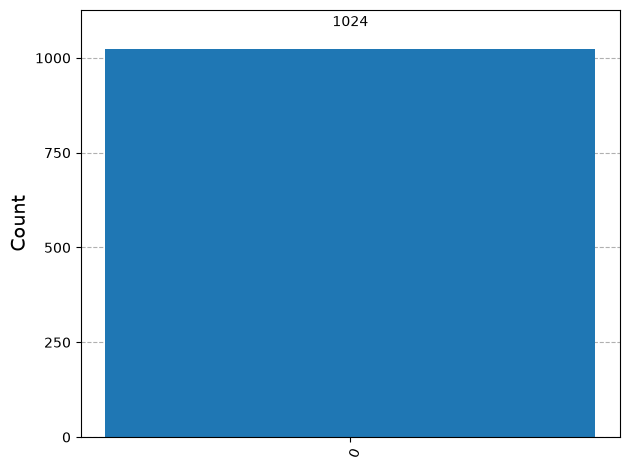

In [ ]:
def measure_qubit(circuit, bases):
    '''
    Inputs:
        circuit      (list) : contains the qubits sent by Alice
        bases        (list) : bit string b tilde
    Outputs:
        measurements (list) : bit string k tilde
    '''
    measurements = []
    
# ------------------------------------------------
      aer_sim = Aer.get_backend('aer_simulator')
      result = aer_sim.run(circuit[i], shots=1024, memory=True).result()
      measured_bit = int(result.get_memory()[0])
      measurements.append(measured_bit)
    return measurements

#Medimos y obtenemos los bits medidos de Bob
bob_results = measure_qubit(protocol,bob_bases)

print("base = " + str(bob_bases[0]))
display(protocol[0].draw(output='mpl'))
aer_sim = Aer.get_backend('aer_simulator')
job = aer_sim.run(protocol[0])
plot_histogram(job.result().get_counts())

Como Bob elegió la misma base que Alice, aseguramos que obtiene el resultado `0`. Sin embargo, pudo haber pasado que la elección aleatoria de Bob no fuese la misma de Alice, por lo que Bob tendría un $50 \%$ de coincidir con el bit que quiso enviar Alice, como es en el siguiente caso

base de Alice = 0
base de Bob = 1


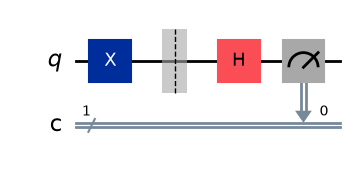

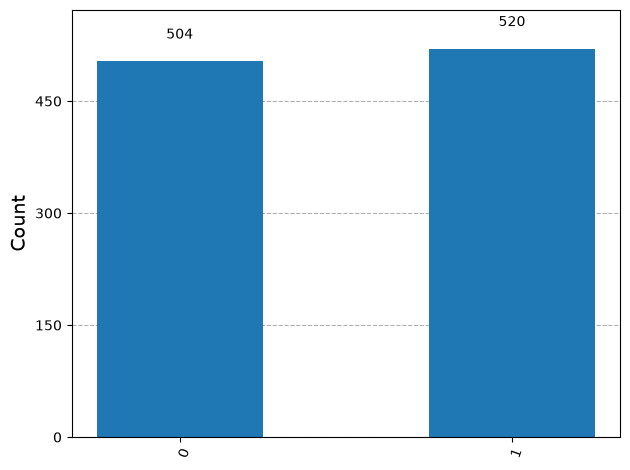

In [40]:
bit_index = 6
protocol[bit_index].draw(output='mpl')
aer_sim = Aer.get_backend('aer_simulator')
print("base de Alice = " + str(alice_bases[bit_index]))
print("base de Bob = " + str(bob_bases[bit_index]))
display(protocol[bit_index].draw(output='mpl'))
job = aer_sim.run(protocol[bit_index])
plot_histogram(job.result().get_counts())

## Paso 4

Alice hace público las bases en que codificó sus qubits y Bob revela en qué base los midió. Deberás completar la función `remove_garbage` que descartará los bits cuando no se cumple $b_i = \tilde{b}_i$. En el caso que la última condición sí se cumpla, deberás añadir los bits a la lista `good_bits`

In [ ]:
def remove_garbage(a_bases, b_bases, bits):
    '''
    Inputs:
        a_bases   (list) : bit string b
        b_bases   (list) : bit string b tilde
        bits      (list) : bits that we keep or discard
    Outputs:
        good_bits (list): contains the bits we keep
    '''
    good_bits = []
#--------------------------------------------------------

#--------------------------------------------------------
    return good_bits

De esta forma, Alice y Bob descartan los bits que no utilizarán, quedando así los bits que formarán parte de la clave secreta

In [42]:
#Alice y Bob remueven los qubit que no se van a utilizar
alice_key = remove_garbage(alice_bases, bob_bases, alice_bits)
print(alice_key)

bob_key = remove_garbage(alice_bases, bob_bases, bob_results)
print(bob_key)

len(bob_key)

[np.int64(0), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(0), np.int64(1), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(1), np.int64(0), np.int64(0), np.int64(0), np.int64(1), np.int64(1), np.int64(1), np.int64(0), np.int64(1), np.int64(0), np.int64(1), np.int64(1), np.int64(0), np.int64(1), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(1), np.int64(0), np.int64(0), np.int64(1), np.int64(1), np.int64(0), np.int64(0), np.int64(0), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(0), np.int64(0), np.int64(1), np.int64(0), np.int64(0)]
[0, 1, 1, 1, 1, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 1, 1, 1, 0, 1, 0, 1, 1, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 1, 0, 0, 0, 1, 1, 1, 1, 0, 0, 1, 0, 0]


48

## Paso 5

Parte de la clave secreta de Alice y Bob se utilizan para verificar si comparten la misma cadena de bits. Para hacer esta comparación, utilizamos la función `sample_bits` con la que extraemos aleatoriamente un número de bits de la clave, que indicamos en `selection`

In [43]:
def sample_bits(bits, selection):
    '''
    Inputs:
        bits      (list) : bit string
        selection (list) : bits that we select from the list "bits"
    Outputs:
        sample    (list) : sample bits to compare
    '''
    sample = []
    for i in selection:
        # usamos np.mod para asegurarnos que el bit que escibimos siempre
        # esté en la lista de rango:
        i = np.mod(i,len(bits))
        # pop(i) elimina el elemento de la lista con índice i
        sample.append(bits.pop(i))
    return sample

Notar que Alice y Bob hacen pública esta muestra, pero como los bits ya no son secretos, no serán parte de la clave

In [44]:
# Alice y Bob comparan algunos bits para corroborar de que el protocolo funcionó

# Tamaño de la muestra
sample_size = 15

# Bits a seleccionar
bit_selection = randint(len(alice_key),size= sample_size)

# Definimos la muestra
bob_sample = sample_bits(bob_key, bit_selection)
alice_sample = sample_bits(alice_key, bit_selection)

print("  bob_sample = " + str(bob_sample))
print("alice_sample = "+ str(alice_sample))

  bob_sample = [0, 0, 1, 1, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0]
alice_sample = [np.int64(0), np.int64(0), np.int64(1), np.int64(1), np.int64(0), np.int64(1), np.int64(0), np.int64(0), np.int64(0), np.int64(1), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0)]


Si el protocolo funcionó correctamente sin ninguna interferencia, las muestras (samples) de Alice y Bob deberían coincidir, por lo que la siguiente línea debería entegarnos el valor lógico `True`

In [45]:
bob_sample == alice_sample
print(bob_key)
print(alice_key)
print("El largo de la llave es %i" % len(alice_key))

[1, 1, 1, 1, 0, 0, 1, 0, 0, 1, 1, 1, 0, 1, 0, 1, 0, 0, 0, 1, 0, 0, 1, 1, 0, 0, 1, 1, 1, 0, 0, 1, 0]
[np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(0), np.int64(0), np.int64(1), np.int64(0), np.int64(0), np.int64(1), np.int64(1), np.int64(1), np.int64(0), np.int64(1), np.int64(0), np.int64(1), np.int64(0), np.int64(0), np.int64(0), np.int64(1), np.int64(0), np.int64(0), np.int64(1), np.int64(1), np.int64(0), np.int64(0), np.int64(1), np.int64(1), np.int64(1), np.int64(0), np.int64(0), np.int64(1), np.int64(0)]
El largo de la llave es 33
